# JSON 
* **J**ava **S**cript **O**bject **N**otation (**JSON**)
* It's is a light weight data format used for data exchange. 
* It's heavily used in the web applications. 
### Similarity: 
* It's looks like a dictionary in python like key value pairs . 
* It has inbuilt library that present in python. 

### Advantages: 
* JSON exists as a "sequence of bytes" which is very useful in the case we need to transmit (stream) data over a network.
* Compared to XML, JSON is much smaller, translating into faster data transfers, and better experiences.
* JSON is extremely human-friendly since it is textual, and simultaneously machine-friendly.

### Difference: 
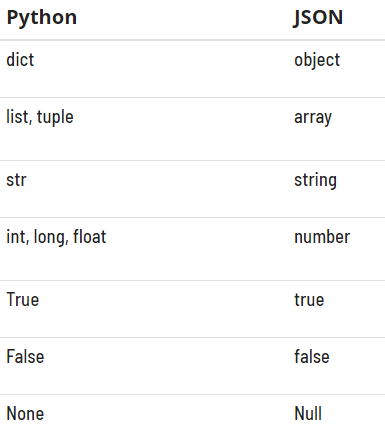
***
Refer This: https://www.python-engineer.com/courses/advancedpython/11-json/
***

### If we need to convert python dictionary to json: 
* It's called **Serialization** or **Encoding**.

In [1]:
import json 

In [4]:
person = {"name": "John", "age": 30, "city": "New York", "hasChildren": False, "titles": ["engineer", "programmer"]} # our dictionary we need to convert to json

person_json = json.dumps(person) # Helps to convert dict to json . . . 
print(person_json)
print()
""" Now this is in json format, because PY: False is changed to JSON: false """

{"name": "John", "age": 30, "city": "New York", "hasChildren": false, "titles": ["engineer", "programmer"]}



' Now this is in json format, because PY: False is changed to JSON: false '

In [12]:
# some more parameters in the json 

person_json = json.dumps(person, indent = 4, separators= ('; ', '='), sort_keys = True)
# Indent of 4 is perferable 
# Seperators helps to seperate with custom symbol, it is tuple. 
# sort_keys helps to sort our keys alphabetically!

print(person_json)

{
    "age"=30; 
    "city"="New York"; 
    "hasChildren"=false; 
    "name"="John"; 
    "titles"=[
        "engineer"; 
        "programmer"
    ]
}


In [15]:
# converting dictionary to json file .. . 

with open('person.json', 'w') as file:
    json.dump(person, file)
    
# we can specify all the parameters here also. 

### If we need to convert JSON to python: 
* It's called **deserialization** or **decoding**. 

we have person file in json format, we want to convert json to python, for that use this code! 

In [18]:
# json file
person_json = json.dumps(person)

# json to python 
person = json.loads(person_json)
print(person)

{'name': 'John', 'age': 30, 'city': 'New York', 'hasChildren': False, 'titles': ['engineer', 'programmer']}


See Now we have py False

If you want to convert from your json file to python file, you can use this code

In [20]:
with open('person.json', 'r') as f:
    py = json.load(f)
    
print(py)

{'name': 'John', 'age': 30, 'city': 'New York', 'hasChildren': False, 'titles': ['engineer', 'programmer']}


### Encoding a Class to json:

Still Now, we have seen about dictionary format, what if we have a class format, let's see the code

#### It has two methods:
##### 1. Creating a custom function. 
##### 2. Using a JSON build in function. 

In [23]:
# Our demo class .. .. 

class User:
    # Custom class with all class variables given in the __init__()
    def __init__(self, name, age, active, balance, friends):
        self.name = name
        self.age = age
        self.active = active
        self.balance = balance
        self.friends = friends
        
class Player:
    # Other custom class
    def __init__(self, name, nickname, level):
        self.name = name
        self.nickname = nickname
        self.level = level
        
user = User('Max', 27, 'yes', 'no', 'yes')

Now we will change the class format to json format

1. Creating a function

In [25]:
# To change the class to json you need to write the custom encoding function. 

def encoding_function(a):
    if isinstance(a, User): # It will check the given attribute is from User class instance or not. 
        return {'name':a.name, 'age':a.age, 'active':a.active, 'balance': a.balance, 'friends':a.friends}
    else:
        raise TypeError("object of the function is not serializable")

userJson = json.dumps(user, default = encoding_function)
print(userJson)

{"name": "Max", "age": 27, "active": "yes", "balance": "no", "friends": "yes"}


This is one way, you can use another method that was build under in json 

2. Using Json build in function

In [29]:
from json import JSONEncoder 

class UserEncoder(JSONEncoder):
    
    def default(self, a):
        if isinstance(a, User):
            return {'name':a.name, 'age':a.age, 'active':a.active, 'balance': a.balance, 'friends':a.friends}
        return JSONEncoder.default(self,o)
    
userJson = json.dumps(user, cls = UserEncoder)
print(userJson)
            

{"name": "Max", "age": 27, "active": "yes", "balance": "no", "friends": "yes"}


### Decode a json to class:
Now we try to convert the class json to python 

In [33]:
user = json.loads(userJson)
print(user)
print(type(user))

{'name': 'Max', 'age': 27, 'active': 'yes', 'balance': 'no', 'friends': 'yes'}
<class 'dict'>


But we have a dictionary here, not a class function. To decode this, we need to create a custom function

In [38]:
def decode_user(dct):
    if User.__name__ in dct:
        return User(name = dct['name'], age = dct['age'], active = dct['active'], balance = dct['balance'], friends = dct['friends']) 
    return dct
  
user = json.loads(userJson, object_hook = decode_user)
print(user)
print(type(user))   

{'name': 'Max', 'age': 27, 'active': 'yes', 'balance': 'no', 'friends': 'yes'}
<class 'dict'>
